# Noise Robustness of Torus Recovery via Delay Embedding

**Reviewer question:** *What is the minimum SNR or spectral prominence required for correct torus recovery?*

**Setup:** We generate a fixed AR(3) process with known pole structure (same as Figure 3),
inject additive white Gaussian noise at controlled SNR levels, and measure how the
delay-embedded manifold degrades. We report:

1. **Visual** degradation of the 3D delay embedding across SNR levels
2. **Quantitative metrics** — reconstruction correlation, PSD divergence, and torus score (TBD)
3. **Critical SNR threshold** where torus topology is lost

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal as sig
from scipy import optimize
from NeuralFieldManifold.embedders import embed

# ============== GLOBAL PLOT STYLE (matches PINN notebook) ==============
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "lines.linewidth": 1.8,
    "lines.markersize": 5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})

color_main = "black"
color_alt = "black"

def prettify(ax, title=None, xlabel=None, ylabel=None, add_legend=False):
    """Unified styling for axes."""
    if title: ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel, labelpad=5)
    if ylabel: ax.set_ylabel(ylabel, labelpad=5)
    ax.grid(alpha=0.0, linestyle="--", linewidth=0.7)
    if add_legend:
        ax.legend(frameon=False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.0)

print("Plot style configured.")

Plot style configured.


## 1. Signal Generation & Noise Injection

In [2]:
def generate_fixed_ar_torus(n_samples=400, ar_order=3, noise_std=0.05, fs=100, seed=42):
    """
    Generate fixed AR process with coefficients designed to produce torus topology.
    
    Key insight: AR process with complex conjugate poles near unit circle
    creates oscillatory (quasi-periodic) behavior.
    
    Args:
        n_samples: Length of signal
        ar_order: AR order (3, 4, 5, or 6 recommended)
        noise_std: Innovation noise level
        fs: Sampling frequency
        
    Returns:
        x: Generated signal (n_samples,)
        coeffs: AR coefficients repeated per timestep (n_samples, ar_order)
    """
    rng = np.random.default_rng(seed)

    if ar_order == 2:
        # AR(2): One complex conjugate pair
        r1 = 0.96
        f1 = 2.0
        theta1 = 2 * np.pi * f1 / fs
        poles = [r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1)]
        
    elif ar_order == 3:
        # AR(3): One complex conjugate pair + one real pole
        r1 = 0.95
        f1 = 2.5
        theta1 = 2 * np.pi * f1 / fs
        pole1 = r1 * np.exp(1j * theta1)
        pole2 = r1 * np.exp(-1j * theta1)
        pole3 = 0.3
        poles = [pole1, pole2, pole3]
        
    elif ar_order == 4:
        # AR(4): Two complex conjugate pairs (creates torus!)
        r1, r2 = 0.93, 0.88
        f1, f2 = 2.0, 3.2
        theta1 = 2 * np.pi * f1 / fs
        theta2 = 2 * np.pi * f2 / fs
        poles = [
            r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1),
            r2 * np.exp(1j * theta2), r2 * np.exp(-1j * theta2)
        ]
        
    elif ar_order == 5:
        # AR(5): Two complex pairs + one real
        r1, r2 = 0.92, 0.87
        f1, f2 = 1.8, 2.9
        theta1 = 2 * np.pi * f1 / fs
        theta2 = 2 * np.pi * f2 / fs
        poles = [
            r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1),
            r2 * np.exp(1j * theta2), r2 * np.exp(-1j * theta2),
            0.4
        ]
        
    elif ar_order == 6:
        # AR(6): Three complex conjugate pairs
        r1, r2, r3 = 0.91, 0.86, 0.80
        f1, f2, f3 = 1.7, 2.7, 4.1
        theta1 = 2 * np.pi * f1 / fs
        theta2 = 2 * np.pi * f2 / fs
        theta3 = 2 * np.pi * f3 / fs
        poles = [
            r1 * np.exp(1j * theta1), r1 * np.exp(-1j * theta1),
            r2 * np.exp(1j * theta2), r2 * np.exp(-1j * theta2),
            r3 * np.exp(1j * theta3), r3 * np.exp(-1j * theta3)
        ]
    else:
        raise ValueError("ar_order must be 2, 3, 4, 5, or 6")
    
    # Convert poles to AR coefficients
    ar_poly = np.poly(poles)
    coeffs = np.real_if_close(-ar_poly[1:], tol=1e6).astype(float)
    
    # Generate AR process
    x = np.zeros(n_samples)
    x[:ar_order] = noise_std * rng.standard_normal(ar_order)
    
    for t in range(ar_order, n_samples):
        ar_sum = sum(coeffs[i] * x[t - i - 1] for i in range(ar_order))
        x[t] = ar_sum + noise_std * rng.standard_normal()
    
    # Normalize
    x = x / (np.std(x) + 1e-8)
    
    # Return coeffs as (n_samples, ar_order) for TVAR format compatibility
    coeffs_expanded = np.tile(coeffs, (n_samples, 1))
    
    return x, coeffs_expanded

def add_noise_at_snr(x_clean, snr_db, rng=None):
    """
    SNR_dB = 10 * log10(P_signal / P_noise)
    """
    if rng is None:
        rng = np.random.default_rng()
    p_signal = np.mean(x_clean ** 2)
    p_noise = p_signal / (10 ** (snr_db / 10))
    noise = rng.standard_normal(len(x_clean)) * np.sqrt(p_noise)
    
    return x_clean + noise

In [3]:
# --- Parameters ---
AR_ORDERS = [2, 4]
N_SAMPLES = 600
TAU = 8
FS = 100
SNR_LEVELS_DB = np.arange(0, 35, 5).tolist()  # 0 to 30 dB, step 5
SNR_VIZ = [30, 20, 10, 5]  # subset for 3D visualization
N_TRIALS = 20

# Generate clean signals for each AR order
clean_signals = {}
clean_embeddings = {}
for p in AR_ORDERS:
    x, coeffs = generate_fixed_ar_torus(n_samples=N_SAMPLES, ar_order=p, fs=FS, seed=42)
    clean_signals[p] = x
    clean_embeddings[p] = np.asarray(embed(jnp.array(x), m=3, tau=TAU))
    print(f"AR({p}) coefficients: {np.round(coeffs[0], 4)}")

t = np.arange(N_SAMPLES) / FS
print(f"\nSNR grid: {SNR_LEVELS_DB} dB  ({len(SNR_LEVELS_DB)} levels)")
print(f"Trials per (order, SNR): {N_TRIALS}")



AR(2) coefficients: [ 1.9049 -0.9216]
AR(4) coefficients: [ 3.5699 -4.8217  2.9206 -0.6698]

SNR grid: [0, 5, 10, 15, 20, 25, 30] dB  (7 levels)
Trials per (order, SNR): 20


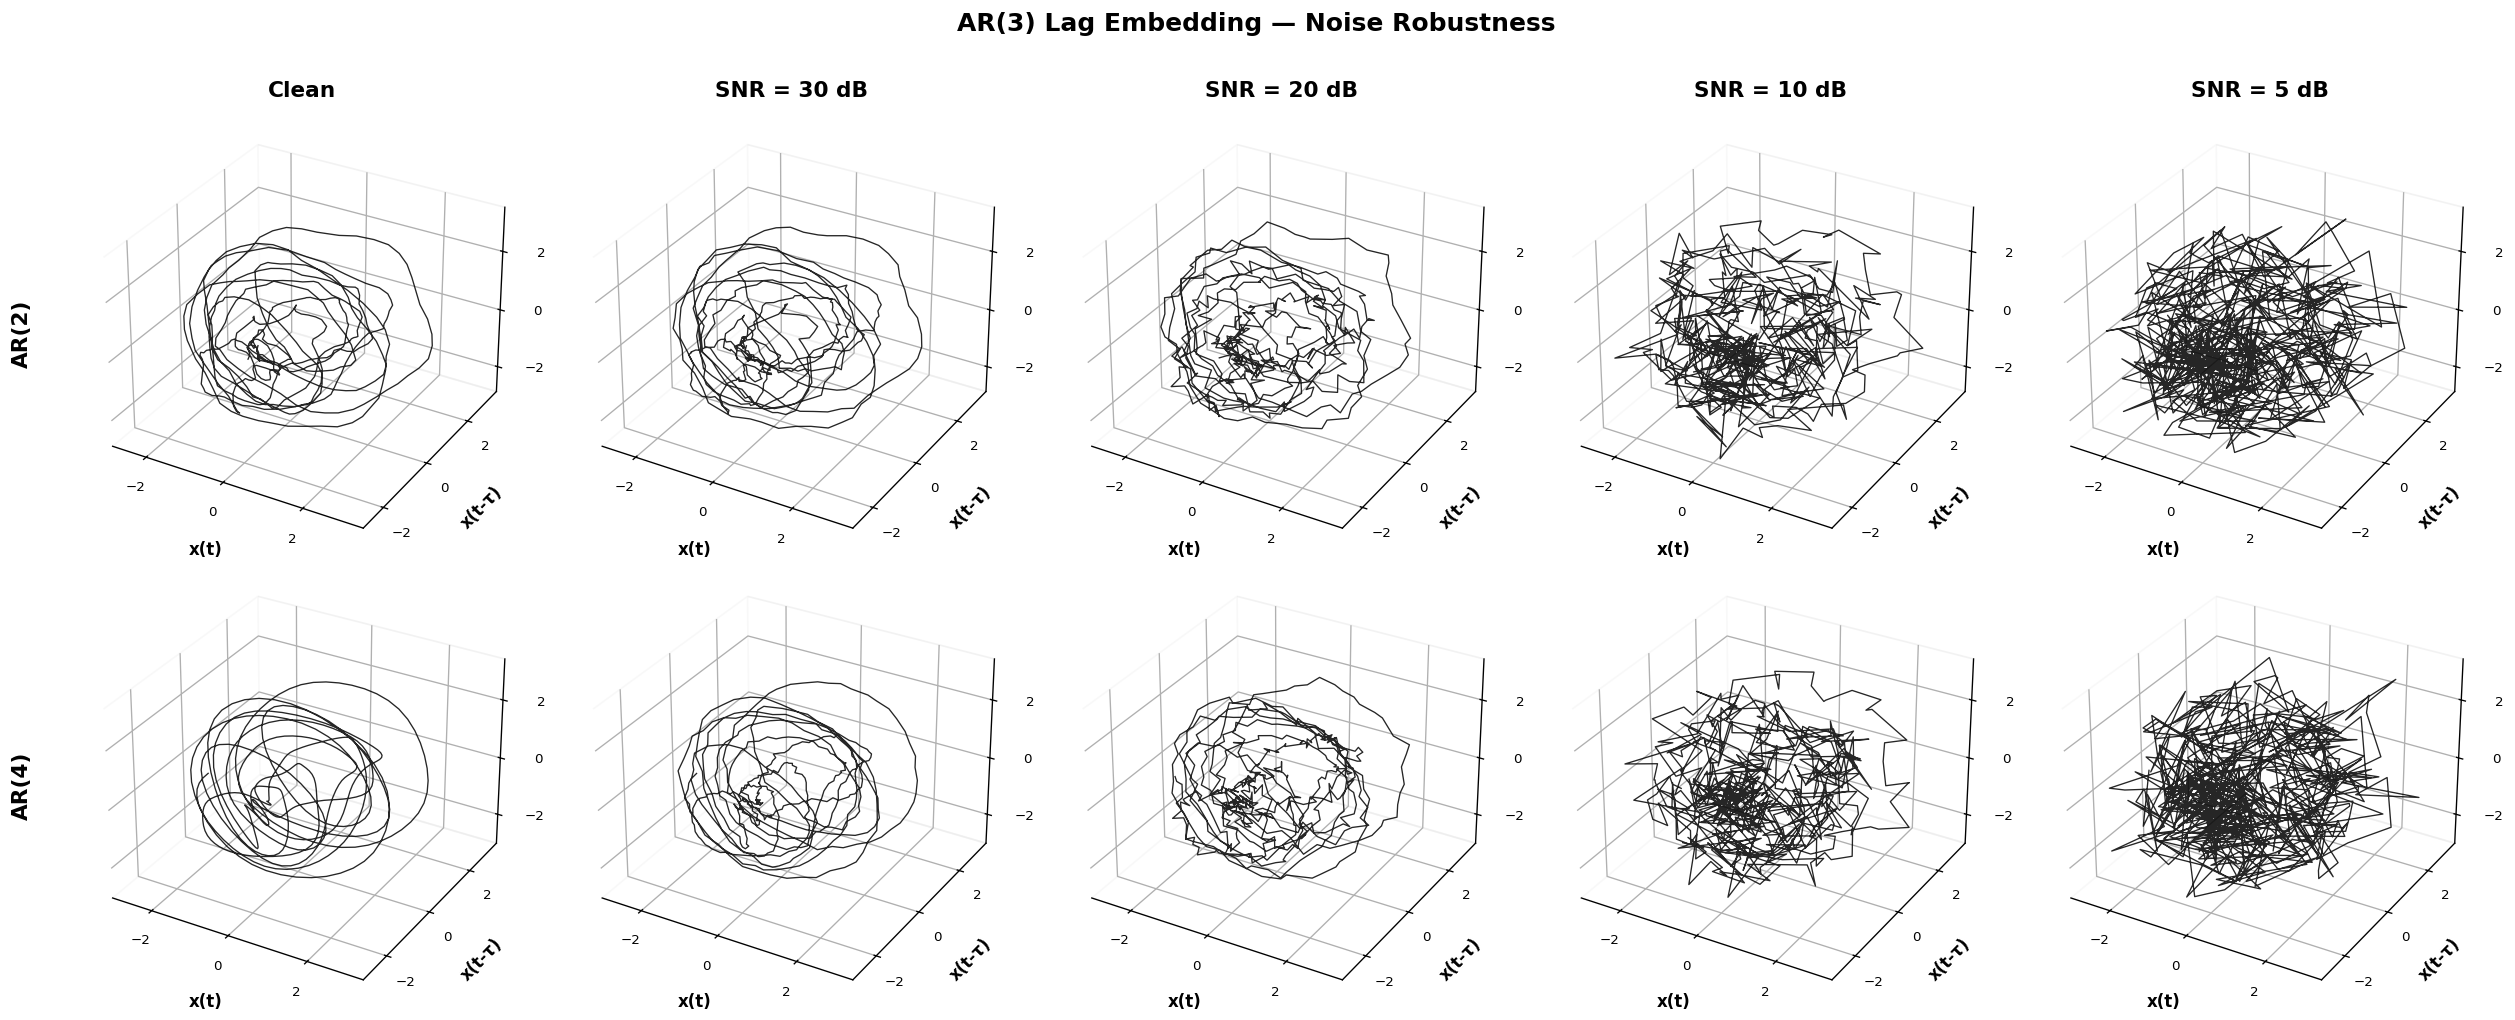

In [4]:
from matplotlib.ticker import MaxNLocator

all_snrs_viz = ["Clean"] + SNR_VIZ
ncols = len(all_snrs_viz)
nrows = len(AR_ORDERS)

fig = plt.figure(figsize=(4.2 * ncols, 4.2 * nrows))

for row, p in enumerate(AR_ORDERS):
    x_clean_p = clean_signals[p]
    X_clean_p = clean_embeddings[p]

    # Pre-compute embeddings for axis limits (per order)
    rng = np.random.default_rng(0)
    embs = [X_clean_p]
    for snr_db in SNR_VIZ:
        x_noisy = add_noise_at_snr(x_clean_p, snr_db, rng=rng)
        embs.append(np.asarray(embed(jnp.array(x_noisy), m=3, tau=TAU)))
    all_pts = np.concatenate(embs, axis=0)
    pad = 0.05 * (all_pts.max() - all_pts.min())
    ax_min, ax_max = all_pts.min() - pad, all_pts.max() + pad

    rng = np.random.default_rng(0)
    for col, snr_db in enumerate(all_snrs_viz):
        idx = row * ncols + col + 1
        if snr_db == "Clean":
            X_emb = X_clean_p
            label = "Clean"
        else:
            x_noisy = add_noise_at_snr(x_clean_p, snr_db, rng=rng)
            X_emb = np.asarray(embed(jnp.array(x_noisy), m=3, tau=TAU))
            label = f"SNR = {snr_db} dB"

        ax = fig.add_subplot(nrows, ncols, idx, projection="3d")
        ax.plot(X_emb[:, 0], X_emb[:, 1], X_emb[:, 2], lw=0.8, alpha=0.85, color=color_alt)

        if row == 0:
            ax.set_title(label, fontsize=13, pad=8, fontweight="bold")
        if col == 0:
            ax.text2D(-0.15, 0.5, f"AR({p})", transform=ax.transAxes,
                       fontsize=13, fontweight="bold", va="center", rotation=90)

        ax.set_xlim(ax_min, ax_max)
        ax.set_ylim(ax_min, ax_max)
        ax.set_zlim(ax_min, ax_max)

        ax.set_xlabel("x(t)", labelpad=6, fontsize=10, fontweight="bold")
        ax.set_ylabel("x(t-τ)", labelpad=6, fontsize=10, fontweight="bold")
        ax.zaxis.set_rotate_label(False)
        ax.set_zlabel("x(t-2τ)", labelpad=10, fontsize=10, fontweight="bold", rotation=90)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.zaxis.set_major_locator(MaxNLocator(nbins=4))
        ax.tick_params(axis='both', pad=2, labelsize=8)
        ax.tick_params(axis='z', pad=6)
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

plt.suptitle("AR(3) Lag Embedding — Noise Robustness",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [5]:
def one_torus_fit(points, lam=0.1, hole_ratio=0.5, n_modes=3):
    """
    Fit an elliptical annular band (one-torus) to a 3-D point cloud.

    Objective
    ─────────
    COVERAGE    : Σ dᵢ²  for points outside the band (2-D projected)
    COMPACTNESS : outer ellipse ≤ PCA extents, inner ≥ hole_ratio × outer

    The band is the region between an inner and outer ellipse lying in the
    best-fit plane.  Both ellipses share the same R1/R2 aspect ratio.

    Parameters
    ──────────
    points     : (N, 3) array
    lam        : tradeoff (0 = pure containment, ∞ = locked to PCA)
    hole_ratio : inner radius penalised when R1_in < hole_ratio * R1
                 0.5 keeps a clear hole without being overly restrictive
    n_modes    : Fourier modes for angular-homogeneity penalty
    """
    pts = np.asarray(points, dtype=np.float64)
    N   = len(pts)

    # ── PCA ──────────────────────────────────────────────────────────
    center0  = pts.mean(axis=0)
    centered = pts - center0
    _, S, Vt = np.linalg.svd(centered, full_matrices=False)

    proj     = centered @ Vt.T
    pc_ext   = np.array([
        np.percentile(proj[:, i], 97.5) - np.percentile(proj[:, i], 2.5)
        for i in range(3)
    ])
    pc_range = np.ptp(proj, axis=0)

    u0, v0, n0 = Vt[0], Vt[1], Vt[2]

    # ── initial estimates ────────────────────────────────────────────
    R1_out_tgt = pc_ext[0] / 2.0
    R2_out_tgt = pc_ext[1] / 2.0

    # estimate inner from projected radial distribution
    proj_cu = centered @ u0
    proj_cv = centered @ v0
    rho = np.sqrt((proj_cu / (R1_out_tgt + 1e-12))**2
                + (proj_cv / (R2_out_tgt + 1e-12))**2)
    rho_in  = np.percentile(rho, 15)
    R1_in_tgt = max(R1_out_tgt * rho_in, 1e-3)

    # ── helpers ──────────────────────────────────────────────────────
    def _frame(dn):
        R1_out = np.linalg.norm(dn) + 1e-12
        n_ax   = dn / R1_out
        u      = u0 - np.dot(u0, n_ax) * n_ax
        u_ax   = u / (np.linalg.norm(u) + 1e-12)
        v_ax   = np.cross(n_ax, u_ax)
        v_ax   = v_ax / (np.linalg.norm(v_ax) + 1e-12)
        return R1_out, n_ax, u_ax, v_ax

    def _nearest_phi(cu, cv, R1, R2, iters=4):
        phi = np.arctan2(cv * R1, cu * R2)
        for _ in range(iters):
            cp, sp = np.cos(phi), np.sin(phi)
            dx, dy = cu - R1 * cp, cv - R2 * sp
            g = dx * R1 * sp - dy * R2 * cp
            H = dx * R1 * cp + dy * R2 * sp + (R1*sp)**2 + (R2*cp)**2
            phi -= np.clip(g / (H + 1e-12), -0.5, 0.5)
        return phi

    def _ellipse_dist_2d(cu, cv, R1, R2):
        phi    = _nearest_phi(cu, cv, R1, R2)
        near_u = R1 * np.cos(phi)
        near_v = R2 * np.sin(phi)
        return np.sqrt((cu - near_u)**2 + (cv - near_v)**2), phi

    # ── residuals ────────────────────────────────────────────────────
    def residuals(params):
        c  = params[:3]
        dn = params[3:6]
        R1_out, n_ax, u_ax, v_ax = _frame(dn)
        ratio  = np.exp(params[6])
        R2_out = R1_out * ratio
        R1_in  = np.exp(params[7])
        R2_in  = R1_in * ratio

        dp = pts - c
        h  = dp @ n_ax            # normal (z) offset from the plane
        cu = dp @ u_ax
        cv = dp @ v_ax

        # classify by normalised elliptic radius
        sigma_out_sq = (cu / (R1_out + 1e-12))**2 + (cv / (R2_out + 1e-12))**2
        sigma_in_sq  = (cu / (R1_in  + 1e-12))**2 + (cv / (R2_in  + 1e-12))**2
        outside_outer = sigma_out_sq > 1.0
        inside_inner  = sigma_in_sq  < 1.0

        d_out, _ = _ellipse_dist_2d(cu, cv, R1_out, R2_out)
        d_in,  _ = _ellipse_dist_2d(cu, cv, R1_in,  R2_in)

        # COVERAGE: 2D in-plane + normal offset so optimizer keeps
        # the plane aligned with the data in 3D
        coverage_2d = np.zeros(N)
        coverage_2d[outside_outer] = d_out[outside_outer]
        coverage_2d[inside_inner]  = d_in[inside_inner]
        coverage = np.sqrt(coverage_2d**2 + h**2)

        # COMPACTNESS
        w = lam * np.sqrt(N)
        compact = np.array([
            # outer ≤ PC extents
            w * max(0.0, 2*R1_out - pc_ext[0]) / (pc_ext[0] + 1e-12),
            w * max(0.0, 2*R2_out - pc_ext[1]) / (pc_ext[1] + 1e-12),
            # hole: inner ≥ hole_ratio × outer
            3.0 * w * max(0.0, hole_ratio - R1_in / (R1_out + 1e-12)),
            # safety: inner must stay < outer
            3.0 * w * max(0.0, R1_in - R1_out) / (R1_out + 1e-12),
        ])

        # HOMOGENEITY: keep band width uniform around the ring
        phi   = np.arctan2(cv * R1_out, cu * R2_out)
        lam_h = 0.3
        raw   = np.zeros(N)
        raw[outside_outer] = d_out[outside_outer]
        raw[inside_inner]  = -d_in[inside_inner]

        homog = []
        for k in range(1, n_modes + 1):
            homog.append(lam_h * np.sqrt(N) * np.mean(raw * np.cos(k*phi)))
            homog.append(lam_h * np.sqrt(N) * np.mean(raw * np.sin(k*phi)))

        return np.concatenate([coverage, compact, np.array(homog)])

    # ── init & bounds ────────────────────────────────────────────────
    ratio0 = np.clip(R2_out_tgt / (R1_out_tgt + 1e-12), 0.1, 1.0)
    x0 = np.concatenate([
        center0,
        n0 * R1_out_tgt,           # dn: ||dn|| = R1_out, direction = normal
        [np.log(ratio0)],
        [np.log(max(R1_in_tgt, 1e-3))],
    ])

    lb = np.full_like(x0, -np.inf)
    ub = np.full_like(x0,  np.inf)
    max_R1 = pc_range[0] / 2.0
    lb[3:6], ub[3:6] = -max_R1, max_R1
    lb[6] = np.log(0.05)
    ub[6] = np.log(np.clip(pc_range[1]/(pc_range[0]+1e-12), 0.05, 1.0))
    lb[7] = np.log(1e-3)
    ub[7] = np.log(max_R1 + 1e-6)

    x0 = np.clip(x0, lb + 1e-8, ub - 1e-8)

    result = optimize.least_squares(
        residuals, x0,
        bounds=(lb, ub),
        loss='huber', f_scale=1.0,
        max_nfev=6000,
    )

    # ── extract ──────────────────────────────────────────────────────
    c  = result.x[:3]
    dn = result.x[3:6]
    R1_out, n_ax, u_ax, v_ax = _frame(dn)
    ratio  = np.exp(result.x[6])
    R2_out = R1_out * ratio
    R1_in  = np.exp(result.x[7])
    R2_in  = R1_in * ratio

    if abs(np.dot(u_ax, u0)) < abs(np.dot(v_ax, u0)):
        R1_out, R2_out = R2_out, R1_out
        R1_in,  R2_in  = R2_in,  R1_in
        u_ax, v_ax = v_ax, u_ax

    # classify final
    dp = pts - c
    h  = dp @ n_ax                     # normal (z) offset from the plane
    cu = dp @ u_ax
    cv = dp @ v_ax
    sigma_out_sq = (cu/(R1_out+1e-12))**2 + (cv/(R2_out+1e-12))**2
    sigma_in_sq  = (cu/(R1_in+1e-12))**2  + (cv/(R2_in+1e-12))**2
    outside_outer = sigma_out_sq > 1.0
    inside_inner  = sigma_in_sq  < 1.0
    in_band       = (~outside_outer) & (~inside_inner)

    d_out, _ = _ellipse_dist_2d(cu, cv, R1_out, R2_out)
    d_in,  _ = _ellipse_dist_2d(cu, cv, R1_in,  R2_in)

    # 2D in-plane error (mean_error)
    error_2d = np.zeros(N)
    error_2d[outside_outer] = d_out[outside_outer]
    error_2d[inside_inner]  = d_in[inside_inner]

    # 3D error including normal offset (mse)
    error_3d = np.abs(h)                               # in-band: just |h|
    error_3d[outside_outer] = np.sqrt(d_out[outside_outer]**2 + h[outside_outer]**2)
    error_3d[inside_inner]  = np.sqrt(d_in[inside_inner]**2  + h[inside_inner]**2)

    # R² using 2D residuals (mean_error convention)
    ss_res = np.sum(error_2d**2)
    ss_tot = np.sum(np.sum((pts - pts.mean(axis=0))**2, axis=1))
    r_squared = 1.0 - ss_res / (ss_tot + 1e-12)

    return dict(
        center=c, direction=n_ax, u_axis=u_ax, v_axis=v_ax,
        R1=float(R1_out), R2=float(R2_out),
        R1_in=float(R1_in), R2_in=float(R2_in),
        minor_radius=float((R1_out - R1_in + R2_out - R2_in) / 4),
        hole_quality=float(R1_in / (R1_out + 1e-12)),
        r_squared=float(r_squared),
        mse=float(np.mean(error_3d**2)),
        mean_error=float(np.mean(error_2d)),
        frac_inside=float(in_band.sum() / N),
        frac_in_hole=float(inside_inner.sum() / N),
        pc_extents=pc_ext,
        pc_ranges=pc_range,
    )

In [6]:
def two_torus_fit(points, lam=1.0, hole_ratio=0.75, n_modes=3):
    """
    Fit an elliptical torus to a 3-D point cloud.

    Objective
    ─────────
    COVERAGE    : Σ max(0, dᵢ − r)²   — contain the point cloud
    COMPACTNESS : don't exceed PCA extents + protect the hole

    lam   : tradeoff (0 = pure containment, ∞ = locked to PCA)
    hole_ratio : tube radius penalised when r > hole_ratio * min(R1,R2)
                 0.75 is a good default — allows a thick tube but keeps
                 a clear hole even with outliers cutting through it
    """
    pts = np.asarray(points, dtype=np.float64)
    N   = len(pts)

    # ── PCA ──────────────────────────────────────────────────────────
    center0  = pts.mean(axis=0)
    centered = pts - center0
    _, S, Vt = np.linalg.svd(centered, full_matrices=False)

    proj     = centered @ Vt.T
    pc_ext   = np.array([
        np.percentile(proj[:, i], 97.5) - np.percentile(proj[:, i], 2.5)
        for i in range(3)
    ])
    pc_range = np.ptp(proj, axis=0)

    r_tgt  = pc_ext[2] / 2.0
    R1_tgt = max(pc_ext[0] / 2.0 - r_tgt, r_tgt * 0.5)
    R2_tgt = max(pc_ext[1] / 2.0 - r_tgt, r_tgt * 0.5)

    u0, v0, n0 = Vt[0], Vt[1], Vt[2]

    # ── helpers ──────────────────────────────────────────────────────
    def _frame(dn):
        R1   = np.linalg.norm(dn) + 1e-12
        n_ax = dn / R1
        u    = u0 - np.dot(u0, n_ax) * n_ax
        u_ax = u / (np.linalg.norm(u) + 1e-12)
        v_ax = np.cross(n_ax, u_ax)
        v_ax = v_ax / (np.linalg.norm(v_ax) + 1e-12)
        return R1, n_ax, u_ax, v_ax

    def _nearest_phi(cu, cv, R1, R2, iters=4):
        phi = np.arctan2(cv * R1, cu * R2)
        for _ in range(iters):
            cp, sp = np.cos(phi), np.sin(phi)
            dx, dy = cu - R1 * cp, cv - R2 * sp
            g = dx * R1 * sp - dy * R2 * cp
            h = dx * R1 * cp + dy * R2 * sp + (R1*sp)**2 + (R2*cp)**2
            phi -= np.clip(g / (h + 1e-12), -0.5, 0.5)
        return phi

    def _dist(c, n_ax, u_ax, v_ax, R1, R2, pts):
        dp   = pts - c
        h    = dp @ n_ax
        perp = dp - h[:, None] * n_ax
        cu, cv = perp @ u_ax, perp @ v_ax
        phi  = _nearest_phi(cu, cv, R1, R2)
        near = ((R1*np.cos(phi))[:, None] * u_ax
                + (R2*np.sin(phi))[:, None] * v_ax + c)
        return np.linalg.norm(pts - near, axis=1), phi

    # ── residuals ────────────────────────────────────────────────────
    def residuals(params):
        c  = params[:3]
        dn = params[3:6]
        R1, n_ax, u_ax, v_ax = _frame(dn)
        R2 = R1 * np.exp(params[6])
        r  = np.exp(params[7])

        d, phi = _dist(c, n_ax, u_ax, v_ax, R1, R2, pts)

        # COVERAGE: only outside points
        coverage = np.maximum(0.0, d - r)

        # COMPACTNESS: don't exceed PCA extents + protect the hole
        w = lam * np.sqrt(N)
        Rmin = min(R1, R2)
        hole_overshoot = max(0.0, r - hole_ratio * Rmin) / (Rmin + 1e-12)

        compact = np.array([
            w * max(0.0, 2*(R1+r) - pc_ext[0]) / (pc_ext[0] + 1e-12),
            w * max(0.0, 2*(R2+r) - pc_ext[1]) / (pc_ext[1] + 1e-12),
            w * max(0.0, 2*r      - pc_ext[2]) / (pc_ext[2] + 1e-12),
            # hole penalty: 3× weight because losing the hole is
            # geometrically catastrophic (torus → blob)
            3.0 * w * hole_overshoot,
        ])

        # HOMOGENEITY: keep backbone centred
        lam_h = 0.3
        raw   = d - r
        homog = []
        for k in range(1, n_modes + 1):
            homog.append(lam_h * np.sqrt(N) * np.mean(raw * np.cos(k*phi)))
            homog.append(lam_h * np.sqrt(N) * np.mean(raw * np.sin(k*phi)))

        return np.concatenate([coverage, compact, np.array(homog)])

    # ── init & bounds ────────────────────────────────────────────────
    ratio0 = np.clip(R2_tgt / (R1_tgt + 1e-12), 0.1, 1.0)
    x0 = np.concatenate([
        center0,
        n0 * R1_tgt,
        [np.log(ratio0)],
        [np.log(max(r_tgt, 1e-3))],
    ])

    lb = np.full_like(x0, -np.inf)
    ub = np.full_like(x0,  np.inf)
    max_R1 = pc_range[0] / 2.0
    lb[3:6], ub[3:6] = -max_R1, max_R1
    lb[6] = np.log(0.05)
    ub[6] = np.log(np.clip(pc_range[1]/(pc_range[0]+1e-12), 0.05, 1.0))
    lb[7] = np.log(1e-3)
    ub[7] = np.log(pc_range[2] / 2.0 + 1e-6)

    x0 = np.clip(x0, lb + 1e-8, ub - 1e-8)

    result = optimize.least_squares(
        residuals, x0,
        bounds=(lb, ub),
        loss='huber', f_scale=1.0,
        max_nfev=6000,
    )

    # ── extract ──────────────────────────────────────────────────────
    c  = result.x[:3]
    dn = result.x[3:6]
    R1, n_ax, u_ax, v_ax = _frame(dn)
    R2 = R1 * np.exp(result.x[6])
    r  = np.exp(result.x[7])

    if abs(np.dot(u_ax, u0)) < abs(np.dot(v_ax, u0)):
        R1, R2 = R2, R1
        u_ax, v_ax = v_ax, u_ax

    d, _ = _dist(c, n_ax, u_ax, v_ax, R1, R2, pts)
    signed       = d - r
    outside_dist = np.maximum(0.0, signed)
    inside_mask  = signed <= 0

    dp   = pts - c
    perp = dp - (dp @ n_ax)[:, None] * n_ax
    ell  = (perp @ u_ax/(R1+1e-12))**2 + (perp @ v_ax/(R2+1e-12))**2
    in_hole = (ell < 1.0) & (~inside_mask)

    # R² using residuals where inside-volume points have 0 residual
    ss_res = np.sum(outside_dist**2)
    ss_tot = np.sum(np.sum((pts - pts.mean(axis=0))**2, axis=1))
    r_squared = 1.0 - ss_res / (ss_tot + 1e-12)

    return dict(
        center=c, direction=n_ax, u_axis=u_ax, v_axis=v_ax,
        R1=float(R1), R2=float(R2), minor_radius=float(r),
        hole_quality=float(1.0 - r / (min(R1, R2) + 1e-12)),
        r_squared=float(r_squared),
        mse=float(np.mean(outside_dist**2)),
        mean_error=float(np.mean(outside_dist)),
        frac_inside=float(inside_mask.sum() / N),
        frac_in_hole=float(in_hole.sum() / N),
        pc_extents=pc_ext,
        pc_ranges=pc_range,
    )

In [7]:
# --- Compute MSE & frac_inside across AR orders × SNR ---
from collections import defaultdict

all_results = {}  # keyed by ar_order

for p in AR_ORDERS:
    x_clean_p = clean_signals[p]
    res = defaultdict(list)

    for snr_db in SNR_LEVELS_DB:
        mse_scores, mean_errors, frac_scores = [], [], []
        for trial in range(N_TRIALS):
            rng_trial = np.random.default_rng(trial)
            x_noisy = add_noise_at_snr(x_clean_p, snr_db, rng=rng_trial)
            X_emb = np.asarray(embed(jnp.array(x_noisy), m=3, tau=TAU))
            try:
                if p == 2:
                    result = one_torus_fit(X_emb, lam=1.0, hole_ratio=0.75)
                elif p == 4:
                    result = two_torus_fit(X_emb, lam=1.0, hole_ratio=0.75)
                mse_scores.append(result['mse'])
                mean_errors.append(result['mean_error'])
                frac_scores.append(result['frac_inside'])
            except Exception:
                mse_scores.append(np.nan)
                mean_errors.append(np.nan)
                frac_scores.append(np.nan)

        res["snr_db"].append(snr_db)
        res["mse_mean"].append(np.nanmean(mse_scores))
        res["mse_std"].append(np.nanstd(mse_scores))
        res["mean_error_mean"].append(np.nanmean(mean_errors))
        res["mean_error_std"].append(np.nanstd(mean_errors))
        res["frac_mean"].append(np.nanmean(frac_scores))
        res["frac_std"].append(np.nanstd(frac_scores))

    all_results[p] = {k: np.array(v) for k, v in res.items()}
    print(f"AR({p}) done.")

print("All orders computed.")

AR(2) done.
AR(4) done.
All orders computed.


/var/folders/w2/4bn86c516gl31kymqxtwhnmw0000gn/T/ipykernel_25751/3255921550.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


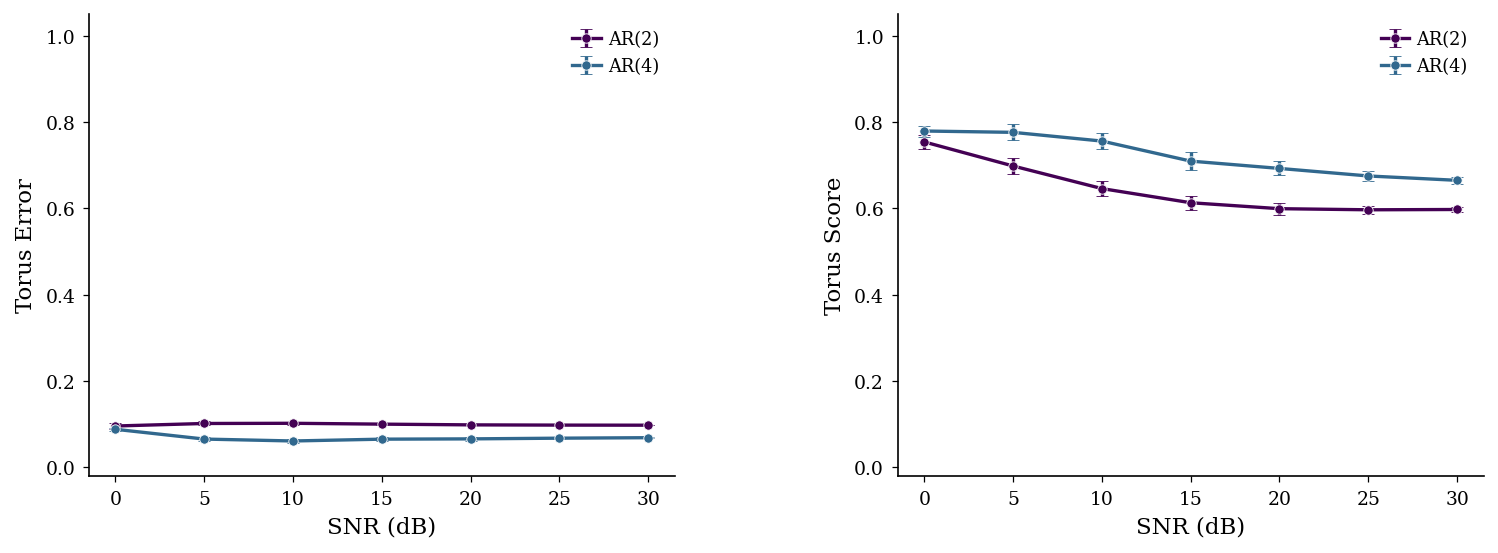

In [11]:

# --- Combined: MSE & Fraction Inside vs. SNR (ICML style) ---
import matplotlib.colors as mcolors

# ── ICML palette (colorblind-friendly) ──
# _ICML_COLORS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]  # blue, vermillion, green, pink
_ICML_COLORS = ["#440154", "#31688e", "#35b779", "#fde725"]
_MARKERS     = ["o", "o", "o", "o"]

with plt.rc_context({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "lines.linewidth": 1.6,
    "lines.markersize": 4.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
}):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"wspace": 0.38})

    for i, p in enumerate(AR_ORDERS):
        r = all_results[p]
        snr  = r["snr_db"]
        c    = _ICML_COLORS[i]
        mk   = _MARKERS[i]

        # ── Panel A: Mean Error ──
        ax1.errorbar(snr, r["mean_error_mean"], yerr=r["mean_error_std"],
                     marker=mk, color=c, label=f"AR({p})",
                     markeredgecolor="white", markeredgewidth=0.4,
                     capsize=3, capthick=1.0, zorder=3)

        # ── Panel B: Fraction Inside ──
        ax2.errorbar(snr, r["frac_mean"], yerr=r["frac_std"],
                     marker=mk, color=c, label=f"AR({p})",
                     markeredgecolor="white", markeredgewidth=0.4,
                     capsize=3, capthick=1.0, zorder=3)

    # ── Axis formatting ──
    for ax in (ax1, ax2):
        ax.set_xlabel("SNR (dB)")
        ax.legend(frameon=False, ncol=1, loc="best", handlelength=1.6,
                  columnspacing=0.8, handletextpad=0.4)

    ax1.set_ylabel("Torus Error")
    ax1.set_ylim(bottom=-0.02, top=1.05)

    ax2.set_ylabel("Torus Score")
    ax2.set_ylim(bottom=-0.02, top=1.05)

    ax1.grid(False)
    ax2.grid(False)

    plt.tight_layout()
    plt.show()


In [9]:
def plot_one_torus_fit(entry, n_surf=60, alpha_surf=0.15):

    pts    = np.asarray(entry['points'])
    center = np.asarray(entry['center'])
    axis   = np.asarray(entry['direction'])
    u_ax   = np.asarray(entry['u_axis'])
    v_ax   = np.asarray(entry['v_axis'])
    R1_out = float(entry['R1'])
    R2_out = float(entry['R2'])
    R1_in  = float(entry['R1_in'])
    R2_in  = float(entry['R2_in'])

    # classify inside / outside band
    dp = pts - center
    cu = dp @ u_ax
    cv = dp @ v_ax
    sigma_out = (cu/(R1_out+1e-12))**2 + (cv/(R2_out+1e-12))**2
    sigma_in  = (cu/(R1_in+1e-12))**2  + (cv/(R2_in+1e-12))**2
    inside = (sigma_out <= 1.0) & (sigma_in >= 1.0)

    # annular band mesh (flat surface between inner and outer ellipses)
    phi      = np.linspace(0, 2 * np.pi, n_surf)
    n_radial = 10
    t        = np.linspace(0, 1, n_radial)
    PHI, T   = np.meshgrid(phi, t)

    R1 = R1_in + T * (R1_out - R1_in)
    R2 = R2_in + T * (R2_out - R2_in)
    bx = R1 * np.cos(PHI)
    by = R2 * np.sin(PHI)

    X = center[0] + bx*u_ax[0] + by*v_ax[0]
    Y = center[1] + bx*u_ax[1] + by*v_ax[1]
    Z = center[2] + bx*u_ax[2] + by*v_ax[2]

    fig = go.Figure()

    # band surface
    fig.add_trace(go.Surface(
        x=X, y=Y, z=Z, opacity=alpha_surf,
        colorscale=[[0, 'steelblue'], [1, 'steelblue']],
        showscale=False, name='Band',
    ))

    # outer ellipse curve
    phi_c = np.linspace(0, 2 * np.pi, n_surf)
    ox = R1_out * np.cos(phi_c)
    oy = R2_out * np.sin(phi_c)
    fig.add_trace(go.Scatter3d(
        x=center[0] + ox*u_ax[0] + oy*v_ax[0],
        y=center[1] + ox*u_ax[1] + oy*v_ax[1],
        z=center[2] + ox*u_ax[2] + oy*v_ax[2],
        mode='lines', line=dict(color='steelblue', width=2, dash='dash'),
        name='outer', showlegend=True,
    ))

    # inner ellipse curve
    ix = R1_in * np.cos(phi_c)
    iy = R2_in * np.sin(phi_c)
    fig.add_trace(go.Scatter3d(
        x=center[0] + ix*u_ax[0] + iy*v_ax[0],
        y=center[1] + ix*u_ax[1] + iy*v_ax[1],
        z=center[2] + ix*u_ax[2] + iy*v_ax[2],
        mode='lines', line=dict(color='coral', width=2, dash='dash'),
        name='inner', showlegend=True,
    ))

    # trajectory segments colored by inside/outside
    first_in = first_out = True
    i = 0
    n = len(pts)
    n_in, n_out = int(inside.sum()), int((~inside).sum())
    while i < n:
        is_in = bool(inside[i])
        j = i + 1
        while j < n and bool(inside[j]) == is_in:
            j += 1
        seg = pts[i:min(j + 1, n)]
        color = 'black' if is_in else 'darkred'
        if is_in:
            show = first_in; first_in = False
            name = f'inside ({n_in})'
            grp  = 'inside'
        else:
            show = first_out; first_out = False
            name = f'outside ({n_out})'
            grp  = 'outside'
        fig.add_trace(go.Scatter3d(
            x=seg[:, 0], y=seg[:, 1], z=seg[:, 2],
            mode='lines', line=dict(color=color, width=3),
            name=name, showlegend=show, legendgroup=grp,
        ))
        i = j

    t_start, t_end = entry['start_sec'], entry['end_sec']
    fig.update_layout(
        title=dict(text=(
            f"Elliptical band {t_start:.1f}–{t_end:.1f} s | "
            f"R1={R1_out:.1f}  R2={R2_out:.1f}  "
            f"R1_in={R1_in:.1f}  R2_in={R2_in:.1f}  "
            f"MSE={entry['mse']:.2f}"
        ), font=dict(size=13)),
        scene=dict(
            xaxis_title='x(t)',
            yaxis_title='x(t-tau)',
            zaxis_title='x(t-2tau)',
        ),
        width=800, height=700,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    fig.show()

In [10]:
result

{'center': array([0.04999609, 0.15905665, 0.07469166]),
 'direction': array([ 0.57540704, -0.61079229,  0.54391131]),
 'u_axis': array([0.42930724, 0.79161526, 0.43478795]),
 'v_axis': array([-0.69613363, -0.01667498,  0.71771855]),
 'R1': 1.5583682062522801,
 'R2': 1.402210147747061,
 'minor_radius': 0.8554841687774851,
 'hole_quality': 0.38990302548345823,
 'r_squared': 0.9922687082839705,
 'mse': 0.023469241832415146,
 'mean_error': 0.06855594044574,
 'frac_inside': 0.666095890410959,
 'frac_in_hole': 0.07534246575342465,
 'pc_extents': array([4.26776649, 4.38011769, 1.66370711]),
 'pc_ranges': array([5.57336363, 5.32960936, 2.37040389])}